In [1]:
import torch
import torch.nn.functional as f
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

import re
import random

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

torch.set_num_threads(1)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [2]:
#extracting datasets
df_cnbc = pd.read_csv('Dataset/cnbc_headlines.csv')
df_guardian = pd.read_csv('Dataset/guardian_headlines.csv')
df_reuters = pd.read_csv('Dataset/reuters_headlines.csv')

#considering only headlines
headline_cnbc = list(df_cnbc['Headlines'])
headline_guardian = list(df_guardian['Headlines'])
headline_reuters = list(df_reuters['Headlines'])

#list of headlines
headline_list = headline_cnbc + headline_guardian + headline_reuters

print("No.of headlines in list: ",len(headline_list))
print(headline_list[:5])

#cleaning dataset

#filtering empty rows
headline_list = [h for h in headline_list if str(h) != 'nan']
print("No.of headlines in list: ",len(headline_list))
print(headline_list[:5])

#removing spaces in headline
def clean_headline(h):
    h = h.strip() #remove the trailing spaces from either end
    h = re.sub(r'\s+', ' ', h) #replace bigger spaces with a single space
    h = h.encode('ascii', 'ignore').decode()  # remove non-ASCII
    return h

headline_list = [clean_headline(h) for h in headline_list]

No.of headlines in list:  53650
['Jim Cramer: A better way to invest in the Covid-19 vaccine gold rush', "Cramer's lightning round: I would own Teradyne", nan, "Cramer's week ahead: Big week for earnings, even bigger week for vaccines", 'IQ Capital CEO Keith Bliss says tech and healthcare will rally']
No.of headlines in list:  53370
['Jim Cramer: A better way to invest in the Covid-19 vaccine gold rush', "Cramer's lightning round: I would own Teradyne", "Cramer's week ahead: Big week for earnings, even bigger week for vaccines", 'IQ Capital CEO Keith Bliss says tech and healthcare will rally', "Wall Street delivered the 'kind of pullback I've been waiting for,' Jim Cramer says"]


In [3]:
print(len(headline_list))

53370


In [4]:
#vocabulary set
unique_words = set()

for headline in headline_list:
    for letter in list(headline):
        unique_words.add(letter)
    
unique_words = ['<S>', '<E>'] + sorted(unique_words)
print("Vocabulary size: ",len(unique_words))

#number to word matrix
num2letter_dict = {i:letter for i, letter in enumerate(unique_words)}

#word to number matrix
letter2num_dict = {letter:i for i, letter in enumerate(unique_words)}


Vocabulary size:  84


In [5]:
print(letter2num_dict)

{'<S>': 0, '<E>': 1, ' ': 2, '!': 3, '"': 4, '#': 5, '$': 6, '%': 7, '&': 8, "'": 9, '(': 10, ')': 11, '*': 12, '+': 13, ',': 14, '-': 15, '.': 16, '/': 17, '0': 18, '1': 19, '2': 20, '3': 21, '4': 22, '5': 23, '6': 24, '7': 25, '8': 26, '9': 27, ':': 28, ';': 29, '?': 30, 'A': 31, 'B': 32, 'C': 33, 'D': 34, 'E': 35, 'F': 36, 'G': 37, 'H': 38, 'I': 39, 'J': 40, 'K': 41, 'L': 42, 'M': 43, 'N': 44, 'O': 45, 'P': 46, 'Q': 47, 'R': 48, 'S': 49, 'T': 50, 'U': 51, 'V': 52, 'W': 53, 'X': 54, 'Y': 55, 'Z': 56, '_': 57, 'a': 58, 'b': 59, 'c': 60, 'd': 61, 'e': 62, 'f': 63, 'g': 64, 'h': 65, 'i': 66, 'j': 67, 'k': 68, 'l': 69, 'm': 70, 'n': 71, 'o': 72, 'p': 73, 'q': 74, 'r': 75, 's': 76, 't': 77, 'u': 78, 'v': 79, 'w': 80, 'x': 81, 'y': 82, 'z': 83}


In [6]:
#building the dataset
block_size = 3

def build_dataset(headline_list):
    context_x = [] #list of all context windows
    targets_y = [] #list of all targets
    for chs in headline_list:
        context_window = [0]*block_size
        for ch in list(chs) + ['<E>']:
            idx = letter2num_dict[ch]
            context_x.append(context_window)
            targets_y.append(idx)
            context_window = context_window[1:] + [idx] #slide context window
        
    #convert the list of context windows and targets into tensors
    context_x = torch.tensor(context_x)
    targets_y = torch.tensor(targets_y)
    return context_x, targets_y

random.seed(42)
random.shuffle(headline_list)
n1 = int(0.8*len(headline_list)) #-> 80% of headline_list
n2 = int(0.9*len(headline_list)) #-> 90% of headline_list

#splitting into train, validation and test datasets
Xtr, Ytr = build_dataset(headline_list[:n1]) #-> 80%
Xval, Yval = build_dataset(headline_list[n1:n2]) #-> 10%
Xtest, Ytest = build_dataset(headline_list[n2:]) #->10%

In [7]:
print("Required initial loss: ",-torch.tensor(1/84).log().item())
#THIS IS DONE, TO ENSURE THE LOSS IS NORMALISED

Required initial loss:  4.430816650390625


**KAIMING NORMALISATION:**
<br>
Normalization formula : 
**Gain/sqrt(fan_in)**
<br>

<u>For tanh:</u>
Gain : (5/3)
<br>

<p> therefore, we use the formula to normalise the initial weights W1 AS: </p>
<strong> W1 = torch.randn((n_embd*block_size, n_hidden), generator=g) * (5/3 / (n_embd*block_size)**0.5) </strong>

In [16]:
#MLP again
n_embd = 10
n_hidden = 200

vocab_size = len(unique_words)

g = torch.Generator().manual_seed(2147483647) # ensures C gets the same random values every run
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd*block_size, n_hidden), generator=g) * (5/3 / (n_embd*block_size)**0.5) #KAIMING NORMALIZATION
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.1
b2 = torch.randn(vocab_size , generator=g) * 0

#Initialising BATCH NORMALISATION PARAMETERS
bngain = torch.ones((1,n_hidden))
bnbias = torch.zeros((1,n_hidden))
bnmean_running = torch.zeros((1,n_hidden))
bnstd_running = torch.ones((1,n_hidden))

#EACH PARAMETER (W1, B1, W2, B2) IS MULTIPLIED WITH A VALUE TO ENSURE THE WEIGHT VALUES ARE SQUASHED TO A NUMBER NEAR TO 0
#THIS IS DONE TO ENSURE THE INITIAL WEIGHT VALUES ARE UNIFORM, A VALUE CLOSE TO 0, AND TO ENSURE THE INITIAL LOSS IS CLOSE TO THE CALCULATED LOSS IN THE ABOVE CELL
#WE CAN CHECK THE RESULTS REFERRING TO THE GRAPHS, AS THE ACTIVATION DISTRIBUTION GRAPH FORMS A PROPER BELL SHAPED CURVE

C = C.to(device)
W1 = W1.to(device)
b1 = b1.to(device)
W2 = W2.to(device)
b2 = b2.to(device)
Xtr = Xtr.to(device)
Ytr = Ytr.to(device)
Xval = Xval.to(device)
Yval = Yval.to(device)
Xtest = Xtest.to(device)
Ytest = Ytest.to(device)
bngain = bngain.to(device)
bnbias = bnbias.to(device)
bnmean_running = bnmean_running.to(device)
bnstd_running = bnstd_running.to(device)



parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) #no.of parameters in total
for p in parameters:
    p.requires_grad = True

24324


## Batch Normalization

After computing pre-activations (emb_flat @ W1 + b1), the values are normalized using Z-score normalization across the batch:

**Formula:** `normalized = (x - mean) / std`

This ensures W2 always receives stable, consistent inputs regardless of how W1 updates. Without this, W2 wastes gradients compensating for W1's shifting output scale.

After normalizing, two learnable parameters scale and shift the result:
- **bngain (γ)** — learnable scale (init=1)
- **bnbias (β)** — learnable shift (init=0)

`output = bngain * normalized + bnbias`

In [17]:
#training the MLP model
max_steps = 200000
batch_size = 256
loss_i = []

for i in range(max_steps):
    #seperating 3.5M examples into mini batches
    batch_x = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[batch_x], Ytr[batch_x]
    
    #forward pass
    emb = C[Xb] #embedding characters
    emb_flat = emb.reshape(emb.shape[0], -1) #flatten emb to form a hidden layer
    pre_activation = emb_flat @ W1 + b1 #pre-activation layer
    bnmeani = pre_activation.mean(0, keepdim=True) #CALCULATE MEAN PER ITERATION/BATCH
    bnstdi = pre_activation.std(0, keepdim=True) #CALCULATE STANDARD DEVIATION PER ITERATION/BATCH
    pre_activation = bngain * (pre_activation - bnmeani) / bnstdi + bnbias #CALCULATE PRE ACTIVATION WITH BATCHNORM AND SHIFT IT

    with torch.no_grad():
        bnmean_running = 0.99 * bnmean_running + 0.01 * bnmeani
        bnstd_running = 0.99 * bnstd_running + 0.01 * bnstdi
    #torch.no_grad ensures backpropagation doesn't happen hence ensuring no waste gradient calculation takes place here
    #now, these calculated values will be used at the end for inference to calculate validation set loss value

    hidden = torch.tanh(pre_activation) #hidden layer (squashing the given inputs b/w -1 and 1 using tanh)
    logits = hidden @ W2 + b2 #output layer
    loss = f.cross_entropy(logits, Yb) #loss function

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward() #implements the backward pass

    #updating using gradient descent
    lr = 0.1 if i<50000 else 0.01 #updating learning rate based on the step count
    for p in parameters:
        p.data += -lr*p.grad #p.data -> value, p.grad-> gradient obtained during backward pass
    
    if i%10000 == 0:
        print("Iteration "+f'{i}'+": "+f'{loss.item()}')
        loss_i.append(loss.detach().cpu().log10().item())

torch.cuda.empty_cache() 
print("Training complete")

Iteration 0: 4.915345191955566
Iteration 10000: 2.133805274963379
Iteration 20000: 2.1016077995300293
Iteration 30000: 2.0308918952941895
Iteration 40000: 1.9948471784591675
Iteration 50000: 1.972360610961914
Iteration 60000: 1.9369986057281494
Iteration 70000: 1.869577407836914
Iteration 80000: 1.822135090827942
Iteration 90000: 1.9023598432540894
Iteration 100000: 2.0910396575927734
Iteration 110000: 1.8310147523880005
Iteration 120000: 2.04119610786438
Iteration 130000: 1.9006894826889038
Iteration 140000: 2.0538694858551025
Iteration 150000: 1.9646034240722656
Iteration 160000: 2.108046531677246
Iteration 170000: 1.79779851436615
Iteration 180000: 1.9092679023742676
Iteration 190000: 1.865123987197876
Training complete


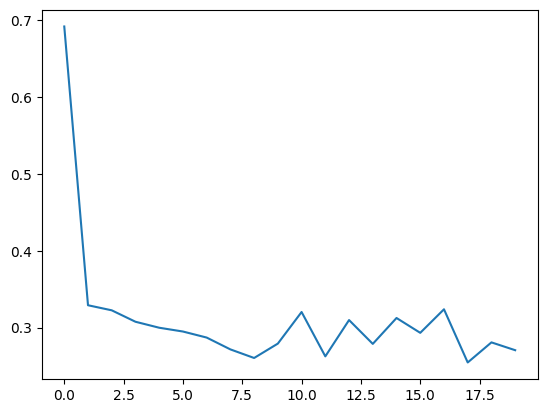

In [18]:
plt.plot(loss_i)

In [19]:
@torch.no_grad #decorator : disables gradient tracking
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xval, Yval),
        'test': (Xtest, Ytest)
    }[split]

    #forward pass
    emb = C[x] #embedding characters
    emb_flat = emb.reshape(emb.shape[0], -1) #flatten emb to form a hidden layer
    pre_activation = emb_flat @ W1 + b1 #pre-activation layer
    pre_activation = bngain * (pre_activation - bnmean_running) / bnstd_running + bnbias #Using the calculated running mean/std values, evaluate pre-activation
    hidden = torch.tanh(pre_activation) #hidden layer (squashing the given inputs b/w -1 and 1 using tanh)
    logits = hidden @ W2 + b2 #output layer
    loss = f.cross_entropy(logits, y) #loss function
    print(split, loss.item())

split_loss('train')
split_loss('val')


train 1.8791531324386597
val 1.8798342943191528
